# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Matthew Burgos

**ID**: mb2557

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [42]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/hw3-matty`


In [43]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?


$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 + (\frac{P-R-S_B}{k_a})(1-\alpha_1) $$

Assume P, R, and S are negligible

$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3  $$

$$ a_1 = exp(-\frac{k_ax}{U}) $$

$$ a_2 = (\frac{k_c}{k_a-k_c})[exp(\frac{-k_cx}{U})-exp(\frac{-k_ax}{U})] $$

$$ a_3 = (\frac{k_n}{k_a-k_n})[exp(\frac{-k_nx}{U})-exp(\frac{-k_ax}{U})] $$


The Streeter-Phelps equation was implemented below using the data from the table. To model the system, I had two separate equations: one before the second waste stream and one after the second waste stream. I used mass balances using the table to get the initial conditions for 0 km < x < 15 km. Then, I used the final state of the system at x=15 and data from the second waste stream to get the initial conditions for x > 15 km. I used a for-loop to iterate through each time step.

The minimum DO concentraion is 2.831981500888709 mg/L

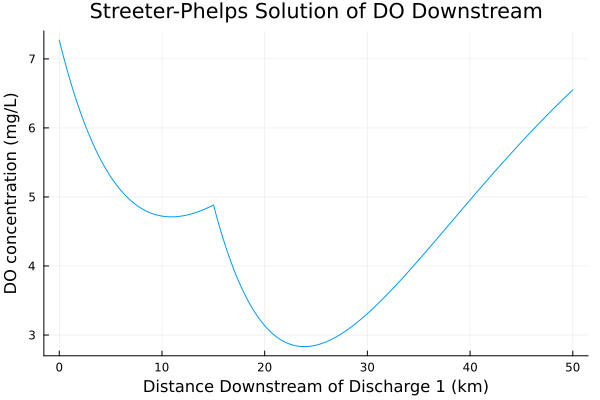

In [44]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = 1000
distances = range(0, stop=50, length=iterations) 
do_concentrations = zeros(iterations)
do_concentrations2 = zeros(iterations+1)

# Calculate initial conditions for x < 15 km
c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
do_concentrations2[1] = c_0
b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

# Variable to check if second waste stream has started
flow2_started = false

for i in 1:iterations
    # x is the distance since the most recent waste stream
    if flow2_started == false
        x = distances[i]
    else
        x = distances[i] - 15
    end

    # Calculate alphas
    alpha_1 = exp(-k_a*x/u)
    alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
    alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

    # Calculate DO concentration and store in array
    c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
    do_concentrations[i] = c

    # Change initial conditions if second waste stream has started
    if x > 15 && flow2_started == false
        c_0 = ((flow_r+flow_s1)*do_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
        b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
        n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
        flow2_started = true
    end
end

# Find minimum value
print("The minimum DO concentraion is ", minimum(do_concentrations), " mg/L")

# Plot
plot(distances, do_concentrations, title="Streeter-Phelps Solution of DO Downstream", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)", legend=false)

Figure 1: Solution to the Streeter-Phelps equation with x=0 being at the first waste stream.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

$$ U\frac{dC}{dx} = k_a(C_s-C(x))+P-R-S_B-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U) $$

Assume P, R, and S are negligible

$$ U\frac{dC}{dx} = k_a(C_s-C(x))-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U) $$

$$ \frac{dC}{dx} = \frac{(k_a(C_s-C(x))-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U))}{U} $$

$$ C(x+\Delta x) = C(x) + \frac{dC}{dx} $$

The minimum DO concentraion for Streeter-Phelps is 2.822548543839264 mg/L
The minimum DO concentraion for numerical integration is 3.4747720458035976 mg/L

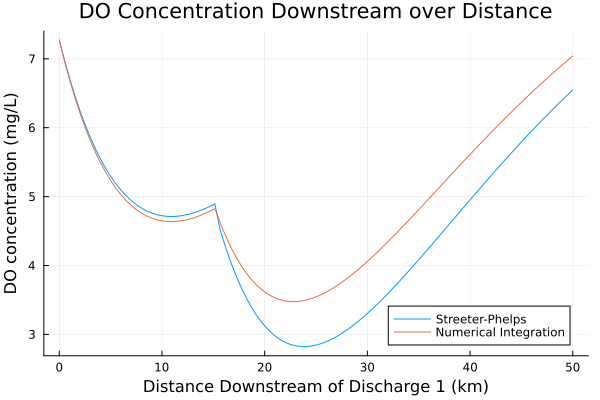

In [45]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = round(Int, 50/0.5)
distances = range(0, 50, iterations) 
streeter_concentrations = zeros(iterations)
numerical_concentrations = zeros(iterations)

function streeter()
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate alphas
        alpha_1 = exp(-k_a*x/u)
        alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
        alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

        # Calculate DO concentration and store in array
        c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
        streeter_concentrations[i] = c

        # Change initial conditions if second waste stream has started
        if x > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*streeter_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end
    end
end


function numerical()
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    numerical_concentrations[1] = c_0 
    
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations-1
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate DO concentration and store in array
        dcdx = (1/u)*(k_a*(c_s-numerical_concentrations[i]) - k_c*b_0*exp(-k_c*x/u) - k_n*n_0*exp(-k_n*x/u)) 
        numerical_concentrations[i+1] = numerical_concentrations[i] + 0.5*dcdx        
        
        # Change initial conditions if second waste stream has started
        if distances[i+1] > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*numerical_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0-b_0*exp(-k_c*x/u)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0-n_0*exp(-k_n*x/u)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end    
    end
end

streeter()
numerical()

# Find minimum value
print("The minimum DO concentraion for Streeter-Phelps is ", minimum(streeter_concentrations), " mg/L")
print("\n")
print("The minimum DO concentraion for numerical integration is ", minimum(numerical_concentrations), " mg/L")

# Plot
plot(distances, streeter_concentrations, title="DO Concentration Downstream over Distance", label="Streeter-Phelps", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")
plot!(distances, numerical_concentrations, label="Numerical Integration", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")



Figure 2: Plot comparing the Streeter-Phelps solution with numerical integration time step of 0.5 km.

As shown in the graph, the two different methods result in very different results. The numerical integration approach has a higher minimum concentraion of around 3.5 mg/L. This difference can be explained because the numerical integration approach is much more time-step-dependent (in this case, the time-step is a distance) than the Streeter Phelps solution. Numerical integration is iterative, so each new calculated concentration is based on the last concentration and the projected slope. This means that different time steps can significantly change the results. The Streeter Phelps solution is not iterative, meaning, once you know the initial conditions, you can know the concentation at any distance simply by plugging in x. With a relatively large delta x such as 0.5, the analytical solution will have more error than the Streeter Phelps solution.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Minimum allowable DO = 4 mg/L + 5% margin of safety.


$$ minimum \quad DO = 4 \frac{mg}{L} + 4(0.05) \frac{mg}{L} $$

$$ minimum \quad DO = 4.2 \frac{mg}{L} $$

If only waste stream 1 is treated, the CBOD and NBOD concentrations from the waste stream are changed. They are multiplied by 1-(% removal). The solution was found by iterating over different treatment levels until the minimum DO level was greater than 3.8 mg/L.

The minimum DO concentraion is 4.201049926815584 mg/L at 68.60000000000005% removal
68.60000000000005% removal is need from waste stream 1

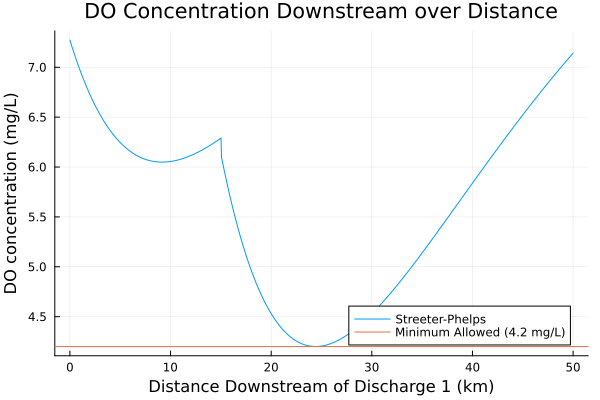

In [49]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = 1000
distances = range(0, 50, iterations) 


function streeter(removal, streeter_concentration)
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1 * (1-removal)) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1 * (1-removal)) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate alphas
        alpha_1 = exp(-k_a*x/u)
        alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
        alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

        # Calculate DO concentration and store in array
        c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
        streeter_concentration[i] = c

        # Change initial conditions if second waste stream has started
        if x > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*streeter_concentration[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end
    end
    return streeter_concentration
end


function find_removal()
    # Loops through different removal rates until minimum DO is greater than 4.2
    removal = 0
    min = 0
    streeter_concentration = zeros(iterations)
    while min < 4.2 && removal < 1
        streeter_concentration = zeros(iterations)
        streeter(removal, streeter_concentration)
        min = minimum(streeter_concentration)
        removal += 0.001
    end
    return streeter_concentration, removal
end


streeter_concentrations, removal = find_removal()

# Find minimum value
print("The minimum DO concentraion is ", minimum(streeter_concentrations), " mg/L at ", removal*100, "% removal")
print("\n")
print(removal*100, "% removal is need from waste stream 1")


# Plot
plot(distances, streeter_concentrations, title="DO Concentration Downstream over Distance", label="Streeter-Phelps", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")
hline!([4.2], label="Minimum Allowed (4.2 mg/L)")



Figure 3: DO Concentration when Waste Stream 1 is Treated to Meet the Minimum DO Standard with 5% Margin of Safety (4.2 mg/L).

If only waste stream 2 is treated, the CBOD and NBOD concentrations from waste stream 2 are changed. They are multiplied by 1-(% removal). The solution was found by iterating over different treatment levels until the minimum DO level was greater than 4.2 mg/L.

The minimum DO concentraion is 4.2000911012361435 mg/L at 63.30000000000005% removal
63.30000000000005% removal is need from waste stream 2

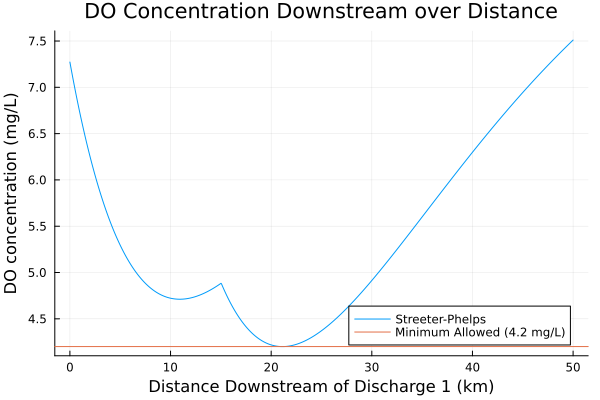

In [50]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = 1000
distances = range(0, 50, iterations) 

function streeter(removal, streeter_concentration)
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate alphas
        alpha_1 = exp(-k_a*x/u)
        alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
        alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

        # Calculate DO concentration and store in array
        c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
        streeter_concentration[i] = c

        # Change initial conditions if second waste stream has started
        if x > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*streeter_concentration[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2 * (1-removal)) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2 * (1-removal)) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end
    end
    return streeter_concentration
end


function find_removal()
    # Loops through different removal rates until minimum DO is greater than 4.2
    removal = 0
    min = 0
    streeter_concentration = zeros(iterations)
    while min < 4.2 && removal < 1
        streeter_concentration = zeros(iterations)
        streeter(removal, streeter_concentration)
        min = minimum(streeter_concentration)
        removal += 0.001
    end
    return streeter_concentration, removal
end


streeter_concentrations, removal = find_removal()

# Find minimum value
print("The minimum DO concentraion is ", minimum(streeter_concentrations), " mg/L at ", removal*100, "% removal")
print("\n")
print(removal*100, "% removal is need from waste stream 2")


# Plot
plot(distances, streeter_concentrations, title="DO Concentration Downstream over Distance", label="Streeter-Phelps", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")
hline!([4.2], label="Minimum Allowed (4.2 mg/L)")



Figure 4: DO Concentration when Waste Stream 2 is Treated to Meet the Minimum DO Standard with 5% Margin of Safety (4.2 mg/L).

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

Based on problem 1.3 it seems like it would be better to treat both waste streams equally. However, we would need more information to tell. Waste stream 2 requires a lower percent removal (68.6%) than waste stream 1 (63.3%) to meet the minimum DO standard. However, waste stream 2 has a greater flow (15,000 m^3/day) than waste stream 1 (10,000 m^3/day). Therefore, we could expect that cost to meet the standard is relatively similar for both, and treating both equally would be ideal because cost is minimized when treatment is distributed. Without more information, however, it is difficult to make this determination. We would need to know the exact cost to treat each waste stream and how cost changes as treatment percentage increases. Our assumption could be wrong, and allocating all treatment to one source may be cheaper than distributing resources to both. Either way, we would need more information about cost to treat the waste streams the cheapest way possible.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

To conduct a Monte Carlo simulation, I slightly altered the code from 1.3, and ran the simulation 10,000 times using random values of river DO from the lognormal distribution. The minimum DO was found for each simulation and then used to construct a running average. The probability of failure is equal to the proportion of simulations that have a DO of below 4.0 mg/L. The 95% confidence interval is the 95% confidence interval of the last simulation. I used the formual: mean += st dev / sqrt(number of simulations)



The probability that the river fails to comply with the 4 mg/L standard is 0.0104
The 95% confidence interval for this simulation is 4.1986391115350585 +- 0.0019047653339307278
95% of confidence intervals that are generated from running this Monte Carlo simulation will contain the true value.

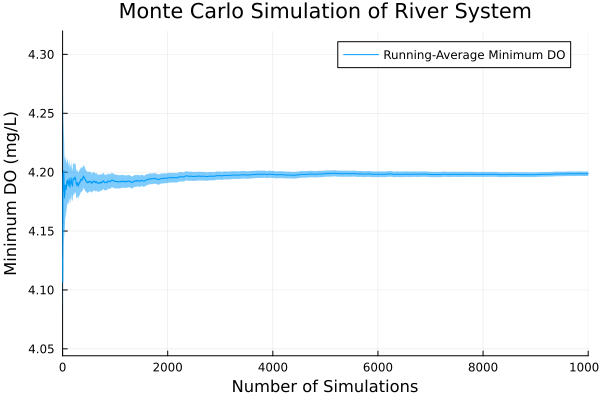

In [48]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = 1000
distances = range(0, 50, iterations) 


function streeter(removal, streeter_concentration, do_river)
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_river + flow_s1*do_s1) / (flow_r+flow_s1)
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1 * (1-removal)) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1 * (1-removal)) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate alphas
        alpha_1 = exp(-k_a*x/u)
        alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
        alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

        # Calculate DO concentration and store in array
        c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
        streeter_concentration[i] = c

        # Change initial conditions if second waste stream has started
        if x > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*streeter_concentration[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end
    end
    return streeter_concentration
end


function find_removal()
    # Loops through different removal rates until minimum DO is greater than 4.2
    removal = 0
    min = 0
    streeter_concentration = zeros(iterations)
    while min < 4.2 && removal < 1
        streeter_concentration = zeros(iterations)
        streeter(removal, streeter_concentration, do_r)
        min = minimum(streeter_concentration)
        removal += 0.001
    end
    return streeter_concentration, removal
end

streeter_concentrations, removal = find_removal()


# Run Monte Carlo simulation
simulations = 10000
samples = rand(LogNormal(2.0, 0.15), simulations)
minimums = zeros(simulations)
running_avg = zeros(simulations)
conf_intervals = zeros(simulations)
fails = 0

# For each simulation, find minimum and calculate running average and 95% confidence interval
for i in 1:simulations
    streeter_concentration = zeros(iterations)
    concentrations = streeter(removal, streeter_concentration, samples[i])
    minimums[i] = minimum(concentrations)
    # Count if the system does not meet the standard
    if minimum(concentrations) < 4
        fails += 1
    end
    running_avg[i] = mean(minimums[1:i])
    conf_intervals[i] = 1.96 * std(minimums[1:i]) / sqrt(i)
end

# Calculate probability of failure and Confidence Interval
print("The probability that the river fails to comply with the 4 mg/L standard is ", fails/simulations)
print("\n")
print("The 95% confidence interval for this simulation is ", running_avg[end], " +- ", conf_intervals[end] )
print("\n")
print("95% of confidence intervals that are generated from running this Monte Carlo simulation will contain the true value.")

plot([1:simulations;], running_avg, ribbon=conf_intervals, xlim=(0, simulations), title="Monte Carlo Simulation of River System", label="Running-Average Minimum DO", xlabel="Number of Simulations", ylabel="Minimum DO (mg/L)")


Figure 5: Monte Carlo Simulation for River with Waste Stream 1 Treatment from Problem 1.3

To decide that my Monte Carlo simulation was sufficienty large, I wanted to make the results as accuarte as possible with a reasonable runtime. I decided that I wanted my runtime to be less than 10 seconds, and iterated over different number of trials until I reached a runtime of a few seconds. I found that 10,000 simulations was sufficient and takes around 7 seconds. Visually, I also made sure that the graph converged to a specific value. The graph is esentially flat near the end of my plot, which is a visual sign that the Monte Carlo simulation is sufficiently large for this problem. I could have also determined the size basde on error, but no minimum Monte Carlo error was provided.

## References

List any external references consulted, including classmates.

Lecture Slides: https://envsys.viveks.me/fall2025/slides/lecture06-1-monte-carlo.html

Lecture Slides: https://envsys.viveks.me/fall2025/slides/lecture05-1-dissolved-oxygen-2.html

To make LaTeX equations: https://latexeditor.lagrida.com/

Julia Lognormal: https://discourse.julialang.org/t/lognormal-distribution-how-to-set-mu-and-sigma/7101

Julia documentation: https://discourse.julialang.org/

